# CHAPTER1 感知机


感知机是我们进入神经网络学习的必经之路。这一章旨在帮助理解感知机的构造，以及如何通过感知机解决简单的分类问题

## 1.1 感知机的结构

感知机能够接受多种输入信号 $x_1, x_2, \ldots, x_n$，然后输出一个信号（0 或 1）。

每个输入信号 $x_i$ 在进入神经元时，会被乘上对应的**权重** $\omega_i$。权重的大小反映了该输入信号的重要程度——权重越大，该信号对最终输出的影响就越大。

将所有加权后的信号求和，再加上一个**偏置**（bias）$b$，就得到了神经元的输入：

$$
z = \omega_1 x_1 + \omega_2 x_2 + \cdots + \omega_n x_n + b = \sum_{i=1}^{n} \omega_i x_i + b
$$

偏置 $b$ 的作用是控制神经元被激活的容易程度：

- 如果 $b > 0$，即使输入信号较小，神经元也更容易输出 1（更容易被激活）
- 如果 $b < 0$，神经元需要更大的加权输入才能被激活

> 我们使用**阈值** $\theta$ 来描述激活条件——当加权和 $\sum \omega_i x_i > \theta$ 时输出 1，否则输出 0，阈值常常是认为规定的。偏置 $b$ 与阈值的关系是 $b = -\theta$。现代神经网络中统一使用偏置的表述，因为它能让公式更加统一和简洁。

最后，净输入 $z$ 会通过一个**激活函数**（此处为阶跃函数）转换为最终的输出：

$$
y = \varphi(z) = 
\begin{cases}
1, & z > 0 \\
0, & z \leq 0
\end{cases}
$$

整个感知机的前向传播可以概括为：

1. **输入**：接收信号 $\mathbf{x} = [x_1, x_2, \ldots, x_n]$
2. **加权求和**：与权重 $\mathbf{w} = [\omega_1, \omega_2, \ldots, \omega_n]$ 做内积
3. **加偏置**：$z = \mathbf{w} \cdot \mathbf{x} + b$
4. **激活**：通过阶跃函数输出 $y \in \{0, 1\}$


## 1.2 从数学角度理解感知机

在上一节中，我们了解到感知机的决策条件是 $z = \mathbf{w} \cdot \mathbf{x} + b > 0$。这个看似抽象的公式，在几何上有着非常直观的含义。

为了方便可视化，我们以 **两个输入信号** 的情况为例。此时，感知机的决策条件为：

$$
z = \omega_1 x_1 + \omega_2 x_2 + b > 0
$$

当 $z = 0$ 时，我们得到了**决策边界**（decision boundary）的方程：

$$
\omega_1 x_1 + \omega_2 x_2 + b = 0
$$

我们不难发现**感知机本质上是在用一条直线将平面划分为两个区域**——直线的一侧输出 1，另一侧输出 0。

<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:43: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_69148/1143682765.py:43: SyntaxWarning: invalid escape sequence '\l'
  label='Output 0 region ($z \leq 0$)')


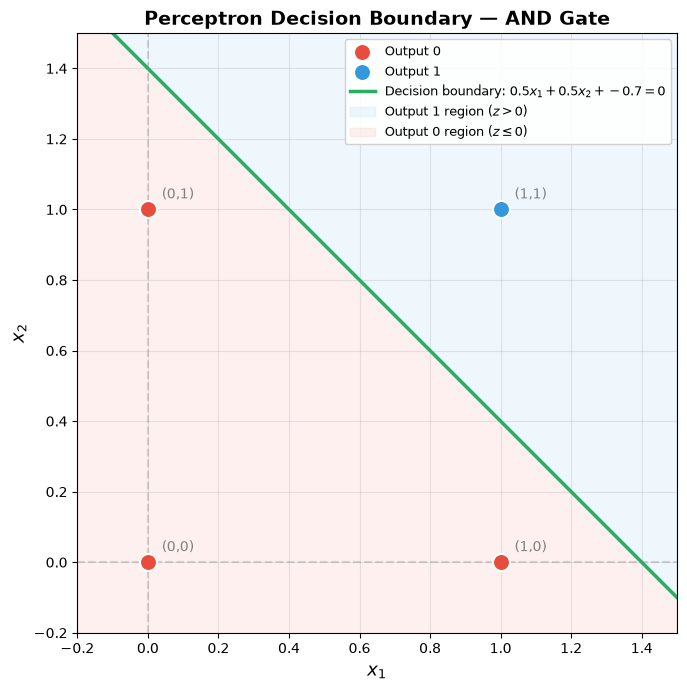

<Figure size 6000x4000 with 0 Axes>

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# AND gate data
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])  # only (1,1) outputs 1

# A set of weights and bias that implements the AND gate
# e.g.: w1=0.5, w2=0.5, b=-0.7
w1, w2, b = 0.5, 0.5, -0.7

# ---- Plot ----
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(-0.2, 1.5)
ax.set_ylim(-0.2, 1.5)
ax.set_xlabel('$x_1$', fontsize=13)
ax.set_ylabel('$x_2$', fontsize=13)
ax.set_title('Perceptron Decision Boundary — AND Gate', fontsize=14, fontweight='bold')

# Data points
ax.scatter(X_and[y_and==0, 0], X_and[y_and==0, 1],
           c='#E74C3C', s=150, marker='o', label='Output 0', zorder=5,
           edgecolors='white', linewidths=1.5)
ax.scatter(X_and[y_and==1, 0], X_and[y_and==1, 1],
           c='#3498DB', s=150, marker='o', label='Output 1', zorder=5,
           edgecolors='white', linewidths=1.5)

# Annotate coordinates
for i, (x1, x2) in enumerate(X_and):
    ax.annotate(f'({x1},{x2})', (x1, x2), textcoords="offset points",
                xytext=(10, 8), fontsize=10, color='gray')

# Decision boundary: x2 = -(w1/w2)*x1 - b/w2
x1_vals = np.linspace(-0.5, 1.5, 100)
x2_vals = -(w1/w2) * x1_vals - b/w2
ax.plot(x1_vals, x2_vals, '#27AE60', linewidth=2.5,
        label=f'Decision boundary: ${w1}x_1 + {w2}x_2 + {b} = 0$')

# Shade regions
ax.fill_between(x1_vals, x2_vals, 1.5, alpha=0.08, color='#3498DB',
                label='Output 1 region ($z>0$)')
ax.fill_between(x1_vals, -0.5, x2_vals, alpha=0.08, color='#E74C3C',
                label='Output 0 region ($z \leq 0$)')

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.3)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.figure(figsize=(6, 4), dpi=1000)
plt.show()

## 1.3 感知机的局限性

感知机看似简单却功能强大，但它有一个致命的局限：**单层感知机只能解决线性可分的问题**。

所谓"线性可分"，是指存在一条直线（高维空间中是超平面）能够将不同类别的数据点完全分开。AND 和 OR 都是线性可分的；但有一类问题天生不是。

**异或门（XOR, Exclusive OR）** 是说明单层感知机局限性的最经典案例。它的真值表如下：

| $x_1$ | $x_2$ | XOR 输出 |
|:-----:|:-----:|:--------:|
|   0   |   0   |    0     |
|   0   |   1   |    1     |
|   1   |   0   |    1     |
|   1   |   1   |    0     |

XOR 的逻辑是："**两个输入不同时输出 1，相同时输出 0**"。下图直观地展示了为什么 XOR 是线性不可分的：

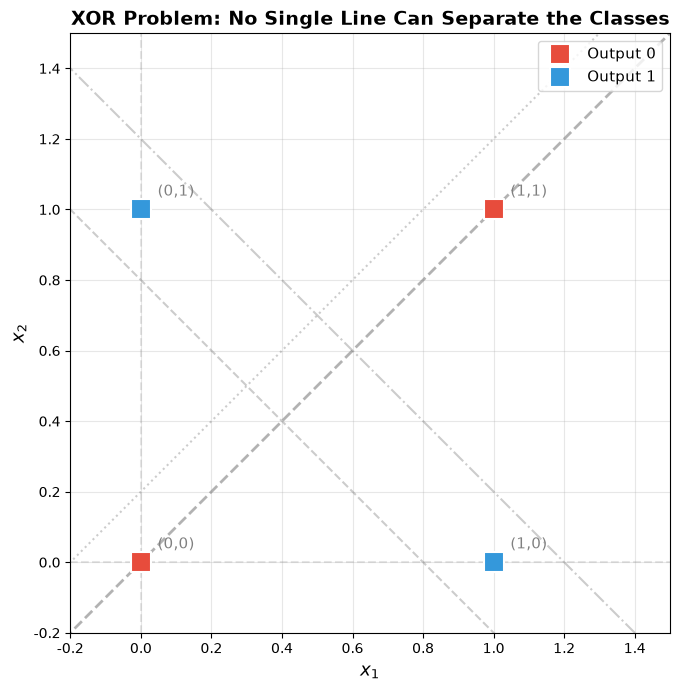

In [6]:
# XOR gate data
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(-0.2, 1.5)
ax.set_ylim(-0.2, 1.5)
ax.set_xlabel('$x_1$', fontsize=13)
ax.set_ylabel('$x_2$', fontsize=13)
ax.set_title('XOR Problem: No Single Line Can Separate the Classes', fontsize=14, fontweight='bold')

# Plot XOR data points
ax.scatter(X_xor[y_xor==0, 0], X_xor[y_xor==0, 1],
           c='#E74C3C', s=200, marker='s', label='Output 0', zorder=5,
           edgecolors='white', linewidths=1.5)
ax.scatter(X_xor[y_xor==1, 0], X_xor[y_xor==1, 1],
           c='#3498DB', s=200, marker='s', label='Output 1', zorder=5,
           edgecolors='white', linewidths=1.5)

# Annotate coordinates
for i, (x1, x2) in enumerate(X_xor):
    ax.annotate(f'({x1},{x2})', (x1, x2), textcoords="offset points",
                xytext=(12, 10), fontsize=11, color='gray')

# Draw several failed line attempts
for (slope, intercept, style) in [
    (-1, 0.8, '--'),
    (-1, 1.2, '-.'),
    (1, 0.2, ':'),
]:
    x1_try = np.linspace(-0.5, 1.5, 100)
    x2_try = slope * x1_try + intercept
    ax.plot(x1_try, x2_try, style, color='gray', alpha=0.4, linewidth=1.5)

# Highlight: the diagonal passes through (0,0) and (1,1), both output 0
x1_diag = np.linspace(-0.5, 1.5, 100)
ax.plot(x1_diag, x1_diag, 'gray', alpha=0.6, linewidth=2, linestyle='--')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.2)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.2)
ax.legend(fontsize=11, loc='upper right')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

从上图可以看出，无论怎样画一条直线，都无法将红色方块（输出 0）和蓝色方块（输出 1）完全分开。**XOR 是非线性可分的**——这是单层感知机无法逾越的鸿沟，但是也并不是完全没有办法。

**通过堆叠多层感知机，理论上可以克服这些局限**。这正是我们下一节要探讨的内容。

## 1.4 多层感知机

既然一条直线不够用，那用**多条直线**组合起来呢？这正是多层感知机的核心思路。

### 1.4.1 感知机解决 XOR？

XOR 可以拆解为更基本的逻辑操作的组合：

$$
\text{XOR}(x_1, x_2) = \text{AND}\big(\text{OR}(x_1, x_2),\; \text{NAND}(x_1, x_2)\big)
$$

用神经网络的语言来说，我们需要：

- **第一层（隐藏层）**：两个神经元，分别实现 NAND 和 OR
- **第二层（输出层）**：一个神经元，对第一层的两个输出做 AND

具体参数如下（注意 NAND 就是把 AND 的权重取反、偏置取反）：

$$
\begin{aligned}
h_1 &= \varphi(-0.5 x_1 - 0.5 x_2 + 0.7) \quad &\text{(NAND 门：只有 (1,1) 输出 0)} \\
h_2 &= \varphi(0.5 x_1 + 0.5 x_2 - 0.2) \quad &\text{(OR 门：只有 (0,0) 输出 0)} \\
y  &= \varphi(0.5 h_1 + 0.5 h_2 - 0.7) \quad &\text{(AND 门：只有 (1,1) 输出 1)}
\end{aligned}
$$

下面我们用代码来验证这个结构确实能解决 XOR：

Two-Layer Perceptron Solving XOR

x1    x2    h1(NAND)   h2(OR)     y(XOR)    
---------------------------------------------
0     0     1          0          0         
0     1     1          1          1         
1     0     1          1          1         
1     1     0          1          0         

Two-layer perceptron successfully solved the XOR problem!


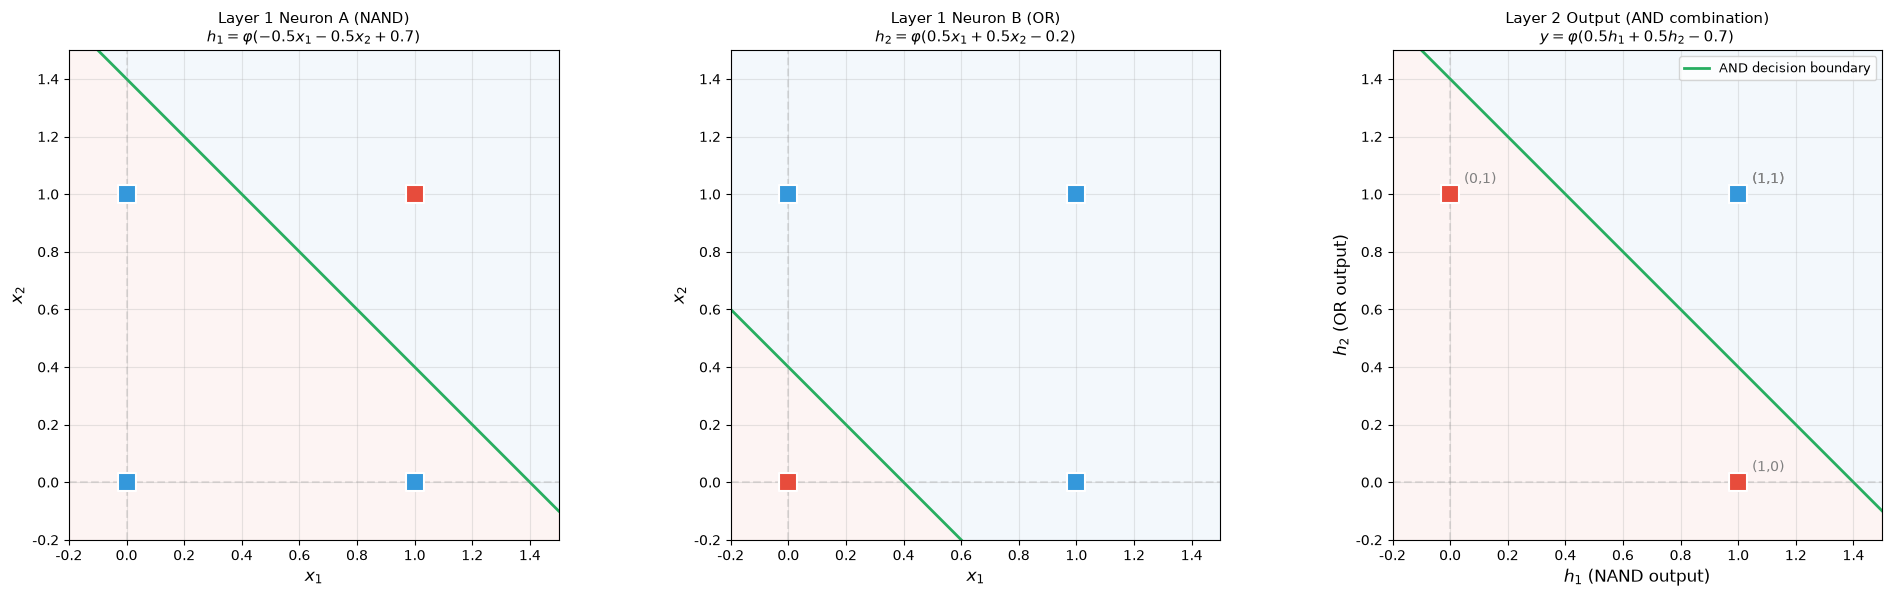

In [9]:
def step_function(z):
    """Step activation function"""
    return np.where(z > 0, 1, 0)

# Layer 1 parameters
# Neuron 1: NAND gate
w11, w12, b1 = -0.5, -0.5, 0.7
# Neuron 2: OR gate
w21, w22, b2 = 0.5, 0.5, -0.2

# Layer 2 parameters: AND gate (inputs are h1 and h2)
w31, w32, b3 = 0.5, 0.5, -0.7

print("=" * 60)
print("Two-Layer Perceptron Solving XOR")
print("=" * 60)
print()
print(f"{'x1':<5} {'x2':<5} {'h1(NAND)':<10} {'h2(OR)':<10} {'y(XOR)':<10}")
print("-" * 45)

for x1, x2 in X_xor:
    # Layer 1
    z1 = w11 * x1 + w12 * x2 + b1
    h1 = step_function(z1)
    z2 = w21 * x1 + w22 * x2 + b2
    h2 = step_function(z2)

    # Layer 2
    z3 = w31 * h1 + w32 * h2 + b3
    y_pred = step_function(z3)

    print(f"{x1:<5} {x2:<5} {h1:<10} {h2:<10} {y_pred:<10}")

print()
print("Two-layer perceptron successfully solved the XOR problem!")

# ---- Visualize the two-layer decision process ----
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

titles = [
    'Layer 1 Neuron A (NAND)\n$h_1 = \\varphi(-0.5x_1 - 0.5x_2 + 0.7)$',
    'Layer 1 Neuron B (OR)\n$h_2 = \\varphi(0.5x_1 + 0.5x_2 - 0.2)$',
    'Layer 2 Output (AND combination)\n$y = \\varphi(0.5h_1 + 0.5h_2 - 0.7)$'
]

# Layer 1 decision boundaries
layer1_params = [
    (w11, w12, b1, 'NAND'),
    (w21, w22, b2, 'OR'),
]

x1_grid = np.linspace(-0.5, 1.5, 100)

for idx, (ax, (w_a, w_b, b_val, name)) in enumerate(zip(axes[:2], layer1_params)):
    ax.set_xlim(-0.2, 1.5)
    ax.set_ylim(-0.2, 1.5)
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(titles[idx], fontsize=11)

    # Layer 1 outputs (in the original input space)
    outputs = step_function(w_a * X_xor[:, 0] + w_b * X_xor[:, 1] + b_val)
    for i, (x1, x2) in enumerate(X_xor):
        color = '#3498DB' if outputs[i] == 1 else '#E74C3C'
        ax.scatter(x1, x2, c=color, s=150, marker='s', zorder=5,
                   edgecolors='white', linewidths=1.5)

    # Decision boundary
    x2_line = -(w_a / w_b) * x1_grid - b_val / w_b
    ax.plot(x1_grid, x2_line, '#27AE60', linewidth=2)
    ax.fill_between(x1_grid, x2_line, 1.5, alpha=0.06, color='#3498DB')
    ax.fill_between(x1_grid, -0.5, x2_line, alpha=0.06, color='#E74C3C')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.2)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

# Third plot: in (h1, h2) feature space, XOR becomes linearly separable!
ax = axes[2]
H = np.array([[step_function(w11*x1 + w12*x2 + b1),
               step_function(w21*x1 + w22*x2 + b2)]
              for x1, x2 in X_xor])

ax.set_xlim(-0.2, 1.5)
ax.set_ylim(-0.2, 1.5)
ax.set_xlabel('$h_1$ (NAND output)', fontsize=12)
ax.set_ylabel('$h_2$ (OR output)', fontsize=12)
ax.set_title(titles[2], fontsize=11)

for i, (h1_val, h2_val) in enumerate(H):
    color = '#3498DB' if y_xor[i] == 1 else '#E74C3C'
    ax.scatter(h1_val, h2_val, c=color, s=150, marker='s', zorder=5,
               edgecolors='white', linewidths=1.5)
    ax.annotate(f'({h1_val},{h2_val})', (h1_val, h2_val),
                textcoords="offset points", xytext=(10, 8), fontsize=10, color='gray')

# In (h1, h2) space, the AND decision boundary can separate XOR
x2_h = -(w31 / w32) * x1_grid - b3 / w32
ax.plot(x1_grid, x2_h, '#27AE60', linewidth=2, label='AND decision boundary')
ax.fill_between(x1_grid, x2_h, 1.5, alpha=0.06, color='#3498DB')
ax.fill_between(x1_grid, -0.5, x2_h, alpha=0.06, color='#E74C3C')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.2)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.2)
ax.legend(fontsize=9)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.4.2 的一般形式

上面的 XOR 示例揭示了一个深刻的原理：**通过堆叠多层感知机，每一层都在对输入做线性变换（权重内积）+非线性映射（激活函数），将数据映射到一个新的向量空间，最终使得原本不可分的问题变得线性可分。**

一般的多层感知机（MLP）结构如下：

<img src="../attachment/图1-1.jpg" width="500" style="display: block; margin: 0 auto;" >

每一层到下一层都是全连接：上一层的每个神经元都与下一层的每个神经元相连，每条连接都有一个独立的权重。


>理论上、只要隐藏层神经元足够多，一个包含单隐藏层的多层感知机就可以以任意精度逼近任何连续函数，前提是激活函数选择Sigmoid。这从理论上保证了神经网络的表达能力。

### 1.4.3 激活函数的重要性（后续还会提及）

值得注意的是，如果去掉激活函数（即 $\varphi(z) = z$，恒等映射），那么多层线性变换的叠加仍然是线性的——多层等价于一层。**非线性激活函数是神经网络拥有强大表达能力的关键**。

现代神经网络中常用的激活函数（ReLU、Sigmoid、Tanh 等）将在后续章节中详细介绍。

## 本章小结

感知机虽然简单，但它奠定了神经网络的基本范式——**加权求和、加偏置、激活**——这个三部曲至今仍然是所有神经网络的核心计算单元。理解了感知机，你就理解了深度学习最底层的构建模块。

下一章我们将进入神经网络的学习，这一章感知机所介绍的内容，实际上就是神经网络中前向传播的过程的概述。